## **Digital Image Processing - CEC Project**

### **Problem Statement: Concrete Crack Detection for Structural Health Monitoring**

**Objective:**

To develop an automated vision-based system that classifies concrete surface images as either positive (containing cracks) or negative (intact).

This project leverages DIP techniques to extract morphological features from structural surfaces. These features are then classified using a Support Vector Machine (SVM).

Manual inspection of concrete is subjective and time-consuming. By applying spatial domain filtering and feature extraction, we can isolate high-frequency components (cracks) from the low-frequency background (intact concrete) to automate defect detection.

In [1]:
!pip install -q kaggle

# set credentials
import os
os.environ['KAGGLE_USERNAME'] = "yesha_gsfcu"
os.environ['KAGGLE_KEY'] = "KGAT_293fbb87d010516b0ea10675c3832e80"

# download dataset
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification

# unzip
!unzip -q -o concrete-crack-images-for-classification.zip

# check files
!ls

Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 233M/233M [00:01<00:00, 164MB/s]

concrete-crack-images-for-classification.zip  Negative	Positive  sample_data


In [2]:
# packages
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import os
import shutil

# organize directories
data_dir = os.path.join('/content', 'crack_dataset')
os.makedirs(data_dir, exist_ok=True)

source_negative = os.path.join('/content', 'Negative')
source_positive = os.path.join('/content', 'Positive')

# move files if they haven't been moved yet
if os.path.exists(source_negative):
    shutil.move(source_negative, data_dir)
if os.path.exists(source_positive):
    shutil.move(source_positive, data_dir)

Raw image data must be standardized before feature extraction. We'll apply some fundamental DIP techniques here:
1. **Spatial Resampling (Geometric Transformation):**
  The original dataset images are downsampled to a fixed $32*32$ spatial grid. This interpolation reduces computational complexity while preserving the macroscopic structural features.

2. **Color Space Conversion:**
  Images are converted to a single luminance channel (Grayscale). Color (chrominance) data is discarded because structural defects are defined by intensity variations (shadows/edges), not hue.

3. **Intensity Normalization (Point Operation):**
  Pixel intensities are scaled and normalized to a specific range. This centers the intensity histogram, standardizing the dynamic range across all images to prevent lighting anomalies from skewing the classification.

In [3]:
#%% transform, load data
transform = transforms.Compose([
    transforms.Resize(32), # downsampled 128x128 images to 32x32
    transforms.Grayscale(), # convert to grayscale
    transforms.ToTensor(), # scale pixel values from 0-255 to 0.0-1.0
    transforms.Normalize((0.5,), (0.5,)), # mean and std for 1 channel
    # Normalize() maps pixel intensities from [0.0, 1.0] to [-1.0, 1.0]
    # bcoz centering img's histogram around 0 helps SVM converge faster
])

batch_size = 4

In [4]:
# load dataset
dataset = torchvision.datasets.ImageFolder("/content/crack_dataset", transform=transform)

# define the split sizes
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# train-test-split
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Train dataset size: 32000
Test dataset size: 8000


#### **Visualize step-by-step Spatial Filtering**

To better understand the structural transformations occurring under the hood;
let's visualize the DIP pipeline on a single high-res image:

1. **Original Grayscale Extraction:** The raw structural data

2. **Geometric Transformation:** Resizing the image

3. **Directional Gradients:** Applying Sobel operators in the X (vertical edges) and Y (horizontal edges) directions separately.

4. **Gradient Magnitude:** The final combined edge map that isolates the high-frequency crack features.

In [5]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# define ore functions
def unnormalize(img_tensor):
    # reverts the PyTorch normalization for visualization and OpenCV processing
    img = img_tensor / 2 + 0.5
    return img.numpy().squeeze()

def apply_sobel_edge_detection(image_np):
    # applies Spatial Domain Filtering (Sobel) to extract gradient magnitude

    # Sobel operators for X and Y directions
    sobelx = cv2.Sobel(image_np, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image_np, cv2.CV_64F, 0, 1, ksize=3)

    # calculate gradient magnitude: G = sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(sobelx**2 + sobely**2)

    # normalize to 0-1 range for consistency in machine learning
    if magnitude.max() > 0:
        magnitude = magnitude / magnitude.max()
    return magnitude

Step-by-step DIP pipeline:


Step 1: Original Grayscale Image


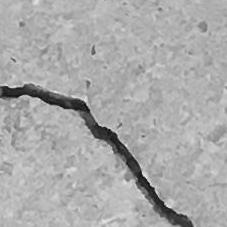


Step 2: Resized Image (Spatial Resampling / Interpolation)


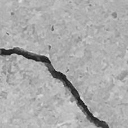


Step 3a: Vertical Edge Detection (Sobel X)


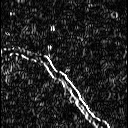


Step 3b: Horizontal Edge Detection (Sobel Y)


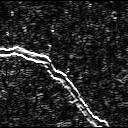


Step 4: Final Gradient Magnitude (The features sent to the SVM)


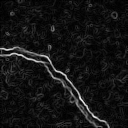

In [9]:
print("Step-by-step DIP pipeline:\n")

crack_dir = '/content/crack_dataset/Positive'
random_img_name = random.choice(os.listdir(crack_dir))
img_path = os.path.join(crack_dir, random_img_name)

# original img
print("\nStep 1: Original Grayscale Image")
raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
cv2_imshow(raw_img)

# resized img
print("\nStep 2: Resized Image (Spatial Resampling / Interpolation)")
resized_img = cv2.resize(raw_img, (128, 128))
cv2_imshow(resized_img)

# apply Sobel X and Y
sobelx_vis = cv2.Sobel(resized_img, cv2.CV_64F, 1, 0, ksize=3)
sobely_vis = cv2.Sobel(resized_img, cv2.CV_64F, 0, 1, ksize=3)
abs_sobelx = cv2.convertScaleAbs(sobelx_vis)
abs_sobely = cv2.convertScaleAbs(sobely_vis)

print("\nStep 3a: Vertical Edge Detection (Sobel X)")
cv2_imshow(abs_sobelx)

print("\nStep 3b: Horizontal Edge Detection (Sobel Y)")
cv2_imshow(abs_sobely)

# calculate gradient magnitude
magnitude_vis = np.sqrt(sobelx_vis**2 + sobely_vis**2)
magnitude_normalized = cv2.normalize(magnitude_vis, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

print("\nStep 4: Final Gradient Magnitude (The features sent to the SVM)")
cv2_imshow(magnitude_normalized)

### **Dimensionality Reduction and Classification**

Now we have to prepare the 2D spatial data for the Machine Learning classifier. The structural features are extracted via the Sobel operator.  

A digital image is naturally a 2D spatial matrix. Traditional classifiers cannot process 2D arrays natively. We apply a structural transformation to unroll the $32*32$ edge maps into a 1D feature vector of length $1024$. This process is called 1-D vectorization.

Finally, these engineered features are passed into a Support Vector Machine (SVM) using a Radial Basis Function (RBF) kernel to find the optimal hyperplane separating the cracked and intact surface features.

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# function to convert PyTorch DataLoader to numpy arrays WITH Edge Detection
def extract_dip_features(dataloader):
    all_features = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Extracting Edge Features"):
        for i in range(images.size(0)):
            # get single image array
            img_np = unnormalize(images[i])

            # apply spatial filter (Sobel)
            edge_map = apply_sobel_edge_detection(img_np)

            # vectorization: flatten the 2D edge map to 1D array
            features = edge_map.flatten()

            all_features.append(features)
            all_labels.append(labels[i].item())

    return np.vstack(all_features), np.array(all_labels)

# extract features from train and test data
X_train, y_train = extract_dip_features(trainloader)
X_test, y_test = extract_dip_features(testloader)

# create and train the SVM model on the DIP features
print("\nTraining SVM Classifier..\n")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# make predictions on the test set
y_pred = svm_model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on Edge Features: {accuracy:.4f}")

# print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Extracting Edge Features: 100%|██████████| 2000/2000 [00:14<00:00, 137.90it/s]



Training SVM Classifier..


Accuracy on Edge Features: 0.9808

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4078
           1       0.98      0.98      0.98      3922

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000

